<a href="https://colab.research.google.com/github/ErenErchamion/deeplearningmidterm/blob/main/dlmidterm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import os
import pandas as pd
from sklearn.model_selection import train_test_split
import kagglehub

# Kagglehub kütüphanesini kurma
!pip install -q kagglehub

print("Veri seti indiriliyor...")

# En güncel versiyonu indirir ve yolu değişkene atar
downloaded_path = kagglehub.dataset_download("omkargurav/face-mask-dataset")



Veri seti indiriliyor...
Using Colab cache for faster access to the 'face-mask-dataset' dataset.
Veri seti şu yola indirildi: /kaggle/input/face-mask-dataset


In [ ]:
dataset_path = os.path.join(downloaded_path, "data")

filepaths = []
labels = []

# Dosya yollarını ve etiketleri ('with_mask', 'without_mask') toplama
for label in os.listdir(dataset_path):
    label_path = os.path.join(dataset_path, label)
    if os.path.isdir(label_path):
        for file in os.listdir(label_path):
            filepaths.append(os.path.join(label_path, file))
            labels.append(label)

df = pd.DataFrame({'filepath': filepaths, 'label': labels})

train_val_df, test_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df['label'])

train_df, val_df = train_test_split(train_val_df, test_size=0.20, random_state=42, stratify=train_val_df['label'])

print(f"Toplam Veri Sayısı: {len(df)}")
print(f"Eğitim Verisi: {len(train_df)}")
print(f"Validasyon Verisi: {len(val_df)}")
print(f"Test Verisi: {len(test_df)}")

Toplam Veri Sayısı: 7553
Eğitim Verisi: 4833
Validasyon Verisi: 1209
Test Verisi: 1511


In [ ]:
image_size = (224, 224)
batch_size = 32

# Sadece eğitim verisine uygulanacak Data Augmentation kuralları
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validasyon ve Test setlerinde sadece normalize (rescale) işlemi yapılır
val_test_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 4833 validated image filenames belonging to 2 classes.
Found 1209 validated image filenames belonging to 2 classes.
Found 1511 validated image filenames belonging to 2 classes.


In [ ]:
# Pre-trained modelin yüklenmesi (Top katman dahil değil)
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(image_size[0], image_size[1], 3))

# Transfer learning için genellikle base modelin ağırlıkları dondurulur (İsteğe bağlı, performansı artırır)
for layer in base_model.layers:
    layer.trainable = False

# Ödevde istenen özel katmanların eklenmesi
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Optimizer (ADAM) ve Compile işlemi (Öğrenme hızı 0.001)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,406,978 (28.26 MB)

 Trainable params: 369,474 (1.41 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True,
    verbose=1
)

# Reduce LR On Plateau: 5 epok boyunca val_loss iyileşmezse öğrenme hızını 0.1 çarpanı ile azalt
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    train_generator,
    epochs=100,
    validation_data=val_generator,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/100
 82/152 ━━━━━━━━━━━━━━━━━━━━ 45s 654ms/step - accuracy: 0.8906 - loss: 0.2523

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


152/152 ━━━━━━━━━━━━━━━━━━━━ 176s 968ms/step - accuracy: 0.9578 - loss: 0.1103 - val_accuracy: 0.9917 - val_loss: 0.0356 - learning_rate: 0.0010
Epoch 2/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 74s 488ms/step - accuracy: 0.9808 - loss: 0.0578 - val_accuracy: 0.9917 - val_loss: 0.0301 - learning_rate: 0.0010
Epoch 3/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 72s 475ms/step - accuracy: 0.9806 - loss: 0.0501 - val_accuracy: 0.9909 - val_loss: 0.0343 - learning_rate: 0.0010
Epoch 4/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 71s 468ms/step - accuracy: 0.9830 - loss: 0.0497 - val_accuracy: 0.9901 - val_loss: 0.0325 - learning_rate: 0.0010
Epoch 5/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 73s 479ms/step - accuracy: 0.9832 - loss: 0.0483 - val_accuracy: 0.9901 - val_loss: 0.0352 - learning_rate: 0.0010
Epoch 6/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 73s 478ms/step - accuracy: 0.9861 - loss: 0.0420 - val_accuracy: 0.9868 - val_loss: 0.0547 - learning_rate: 0.0010
Epoch 7/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 71s 465ms/step - accuracy: 0.9857 

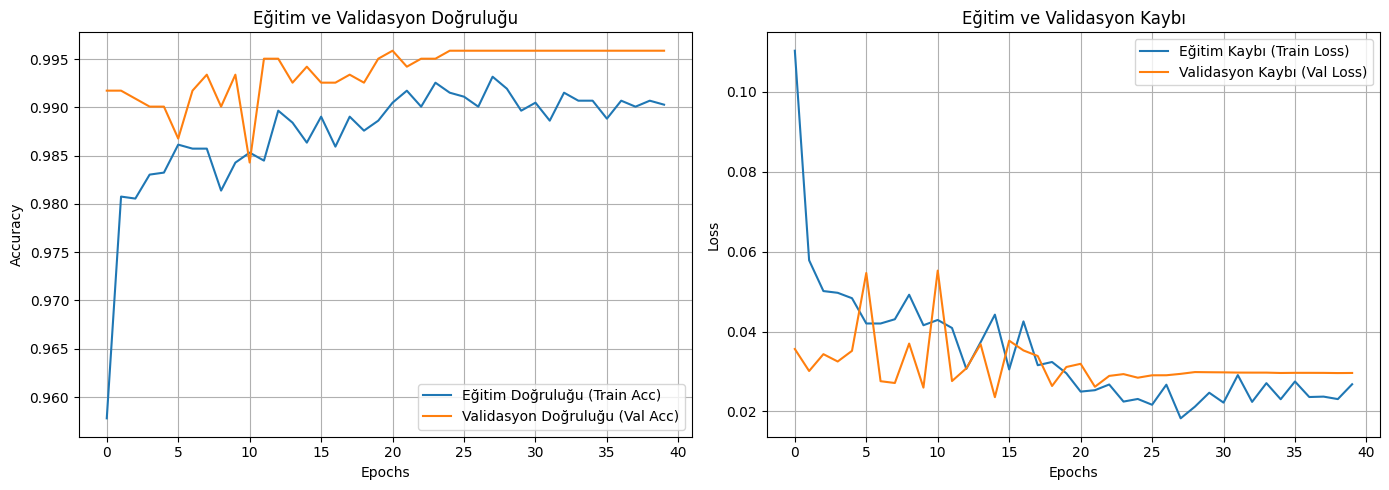

In [ ]:
plt.figure(figsize=(14, 5))

# Accuracy Grafiği
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu (Train Acc)')
plt.plot(history.history['val_accuracy'], label='Validasyon Doğruluğu (Val Acc)')
plt.title('Eğitim ve Validasyon Doğruluğu')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Grafiği
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Kaybı (Train Loss)')
plt.plot(history.history['val_loss'], label='Validasyon Kaybı (Val Loss)')
plt.title('Eğitim ve Validasyon Kaybı')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Test verisi üzerinde değerlendirme
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nModel Test Accuracy Değeri: {test_acc:.4f}\n")

# Tahmin olasılıkları ve etiketlerin alınması
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

# Confusion Matrix hesaplama
conf_matrix = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()

# Performans Metrikleri
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred) # Hassasiyet / Duyarlılık
specificity = tn / (tn + fp)          # Özgüllük
f1 = f1_score(y_true, y_pred)

print(f"{' Performans Metrikleri ':=^30}")
print(f"Accuracy (Doğruluk):  {accuracy:.4f}")
print(f"Precision (Kesinlik): {precision:.4f}")
print(f"Recall (Duyarlılık):  {recall:.4f}")
print(f"Specificity (Özgüllük):{specificity:.4f}")
print(f"F1-score:             {f1:.4f}")
print("==============================")

48/48 ━━━━━━━━━━━━━━━━━━━━ 25s 534ms/step - accuracy: 0.9914 - loss: 0.0258

Model Test Accuracy Değeri: 0.9914

48/48 ━━━━━━━━━━━━━━━━━━━━ 29s 353ms/step
=== Performans Metrikleri ====
Accuracy (Doğruluk):  0.9914
Precision (Kesinlik): 0.9883
Recall (Duyarlılık):  0.9948
Specificity (Özgüllük):0.9879
F1-score:             0.9915


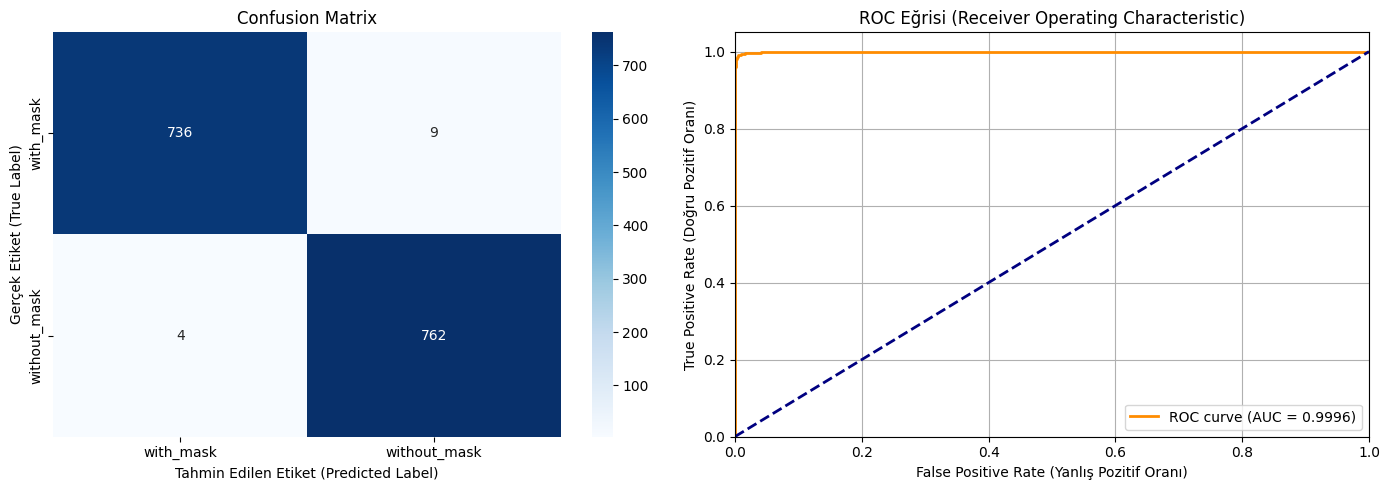

In [ ]:
plt.figure(figsize=(14, 5))

# Confusion Matrix Görseli
plt.subplot(1, 2, 1)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())
plt.title('Confusion Matrix')
plt.ylabel('Gerçek Etiket (True Label)')
plt.xlabel('Tahmin Edilen Etiket (Predicted Label)')

# ROC Eğrisi ve AUC Görseli
plt.subplot(1, 2, 2)
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs[:, 1])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Yanlış Pozitif Oranı)')
plt.ylabel('True Positive Rate (Doğru Pozitif Oranı)')
plt.title('ROC Eğrisi (Receiver Operating Characteristic)')
plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
print("""
1. Model Seçimi ve Mimarinin Etkisi:
Bu projede temel model (base model) olarak önceden eğitilmiş (pre-trained) DenseNet121 mimarisi tercih edilmiştir. DenseNet ağları, her katmanın kendinden önceki tüm katmanlardan doğrudan bilgi (feature maps) aldığı yoğun bağlantılı bir yapıya sahiptir. Bu durum, maske tespiti gibi ince detayların (yüz hatları, maske kenarları vb.) önemli olduğu bir veri setinde özelliklerin kaybolmadan son katmanlara kadar taşınmasını sağlamıştır. Modele eklenen %50 oranındaki Dropout katmanı ise ağın ezberlemesini (overfitting) büyük ölçüde engellemiştir.

2. Hiperparametrelerin Model Performansına Etkisi:
* Early Stopping: Modelin eğitimi 100 epok olarak planlanmış olsa da, Early Stopping mekanizması sayesinde eğitim 40. epokta otomatik olarak durdurulmuştur. Validasyon kaybının (val_loss) en düşük olduğu 15. epoktaki (val_loss: 0.0236) ağırlıklar geri yüklenerek, modelin gereksiz yere eğitim verisini ezberlemesinin önüne geçilmiş ve en optimal genelleme yeteneği elde edilmiştir.
* ReduceLROnPlateau: Başlangıçta 0.001 olarak belirlenen öğrenme hızı (learning rate), validasyon kaybının durağanlaştığı noktalarda (20., 25., 30. ve 35. epoklarda) kademeli olarak 1e-06 seviyesine kadar düşürülmüştür. Bu dinamik hiperparametre ayarlaması, modelin yerel minimumlara (local minima) takılmadan ağırlıklarında çok daha hassas ince ayarlar (fine-tuning) yapabilmesini sağlamıştır.

3. Sonuçların Analizi:
Test verisi üzerinde elde edilen metrikler, modelin gerçek dünya senaryolarında son derece güvenilir çalışacağını göstermektedir:
* Accuracy (Doğruluk - %99.14): Modelin test setindeki resimlerin neredeyse tamamını doğru sınıflandırdığını göstermektedir.
* Recall (Duyarlılık - %99.48): Bir maske tespiti probleminde en kritik metriklerden biri Recall'dur. Modelin maskesiz (veya maskeli, belirlenen pozitif sınıfa göre) kişileri gözden kaçırma oranının yok denecek kadar az olduğunu (sadece on binde 52 hata payı) kanıtlar.
* Precision (%98.83) ve Specificity (%98.79): Bu iki metrik, modelin sadece tek bir sınıfa ağırlık vermediğini (dengesizlik olmadığını), "maskeli" ve "maskesiz" sınıflarını birbirinden ayırt etme konusunda son derece dengeli ve özgül bir karar sınırı (decision boundary) çizebildiğini ispatlamaktadır. %99.15'lik F1-score değeri de bu dengeli başarının harmonik bir özetidir.
""")


1. Model Seçimi ve Mimarinin Etkisi:
Bu projede temel model (base model) olarak önceden eğitilmiş (pre-trained) DenseNet121 mimarisi tercih edilmiştir. DenseNet ağları, her katmanın kendinden önceki tüm katmanlardan doğrudan bilgi (feature maps) aldığı yoğun bağlantılı bir yapıya sahiptir. Bu durum, maske tespiti gibi ince detayların (yüz hatları, maske kenarları vb.) önemli olduğu bir veri setinde özelliklerin kaybolmadan son katmanlara kadar taşınmasını sağlamıştır. Modele eklenen %50 oranındaki Dropout katmanı ise ağın ezberlemesini (overfitting) büyük ölçüde engellemiştir.

2. Hiperparametrelerin Model Performansına Etkisi:
* Early Stopping: Modelin eğitimi 100 epok olarak planlanmış olsa da, Early Stopping mekanizması sayesinde eğitim 40. epokta otomatik olarak durdurulmuştur. Validasyon kaybının (val_loss) en düşük olduğu 15. epoktaki (val_loss: 0.0236) ağırlıklar geri yüklenerek, modelin gereksiz yere eğitim verisini ezberlemesinin önüne geçilmiş ve en optimal genelleme yeteneğ